In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)

In [2]:

train_df = pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\DMart\Train.csv")
test_df = pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\DMart\test.csv")

print(train_df.head())
print(train_df.info())
print(train_df.describe())
print(train_df.isnull().sum())

print(test_df.head())
print(test_df.info())
print(test_df.describe())
print(test_df.isnull().sum())

  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15         9.30          Low Fat         0.016047   
1           DRC01         5.92          Regular         0.019278   
2           FDN15        17.50          Low Fat         0.016760   
3           FDX07        19.20          Regular         0.000000   
4           NCD19         8.93          Low Fat         0.000000   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  182.0950            OUT010   
4              Household   53.8614            OUT013   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2009      Medium               Tier 3   
2                       1999      Medium               Tier

In [9]:
train_original=train_df.copy()
test_original=test_df.copy()

In [10]:
train_df.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

In [5]:
train_df.shape

(8523, 12)

In [6]:
test_df.shape

(5681, 11)

In [11]:
# Standardizing item fat content
train_df['Item_Fat_Content'] = train_df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})
test_df['Item_Fat_Content'] = test_df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})

# Creatng outlet age
train_df['Outlet_Age'] = 2025 - train_df['Outlet_Establishment_Year']
test_df['Outlet_Age'] = 2025 - test_df['Outlet_Establishment_Year']

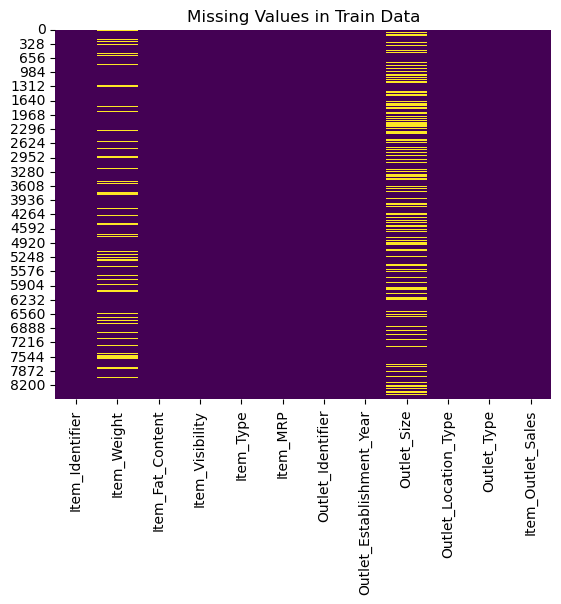

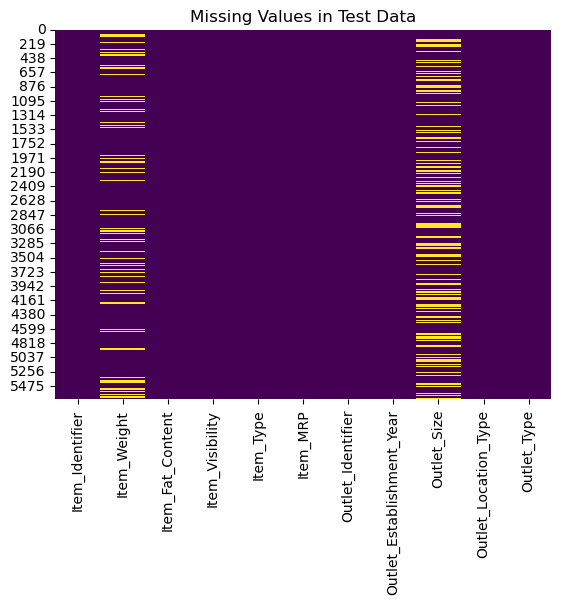

In [4]:
# Heatmap for missing values in train
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in Train Data')
plt.show()

# Heatmap for missing values in test
sns.heatmap(test_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in Test Data')
plt.show()

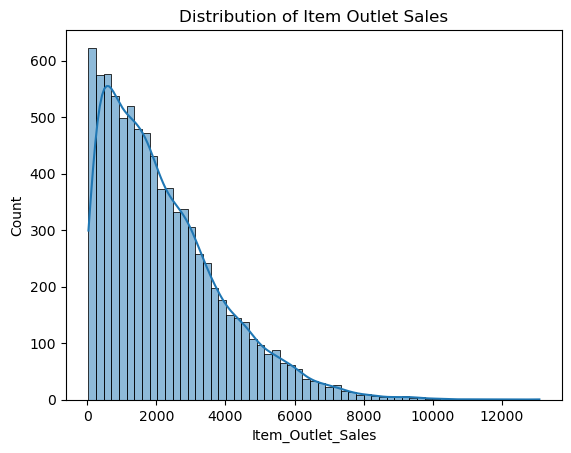

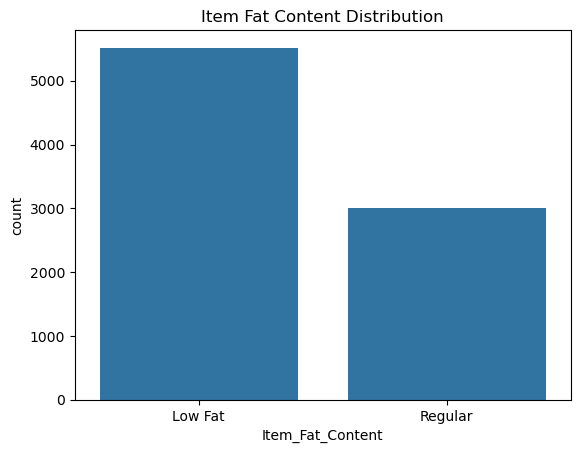

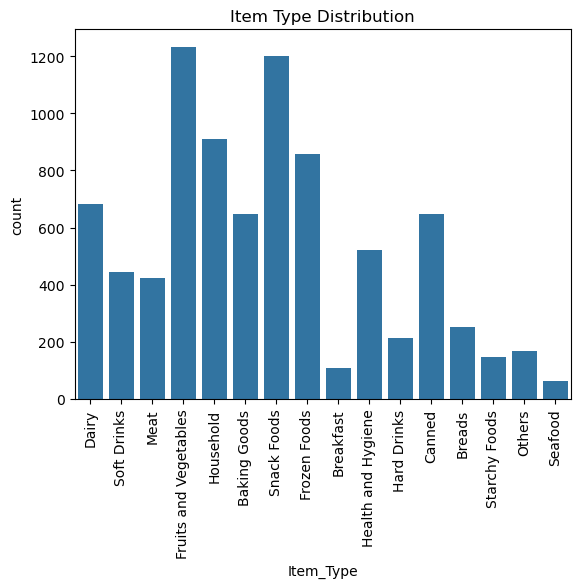

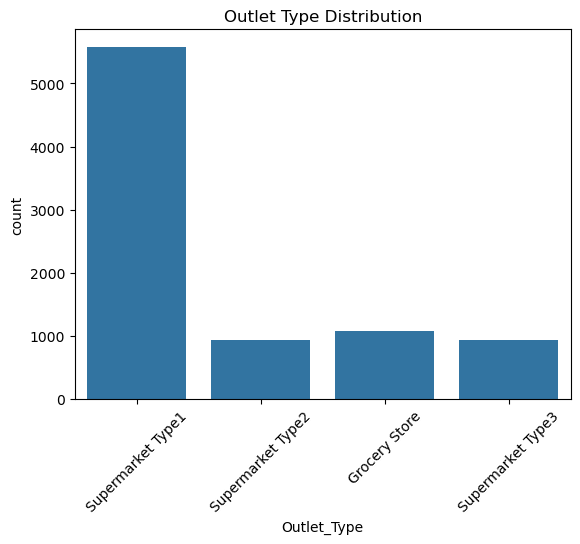

In [16]:
# Distribution of Item_Outlet_Sales
sns.histplot(train_df['Item_Outlet_Sales'], kde=True)
plt.title('Distribution of Item Outlet Sales')
plt.show()

# Countplot for item fat and type
sns.countplot(x='Item_Fat_Content', data=train_df)
plt.title('Item Fat Content Distribution')
plt.show()

sns.countplot(x='Item_Type', data=train_df)
plt.xticks(rotation=90)
plt.title('Item Type Distribution')
plt.show()

sns.countplot(x='Outlet_Type', data=train_df)
plt.xticks(rotation=45)
plt.title('Outlet Type Distribution')
plt.show()

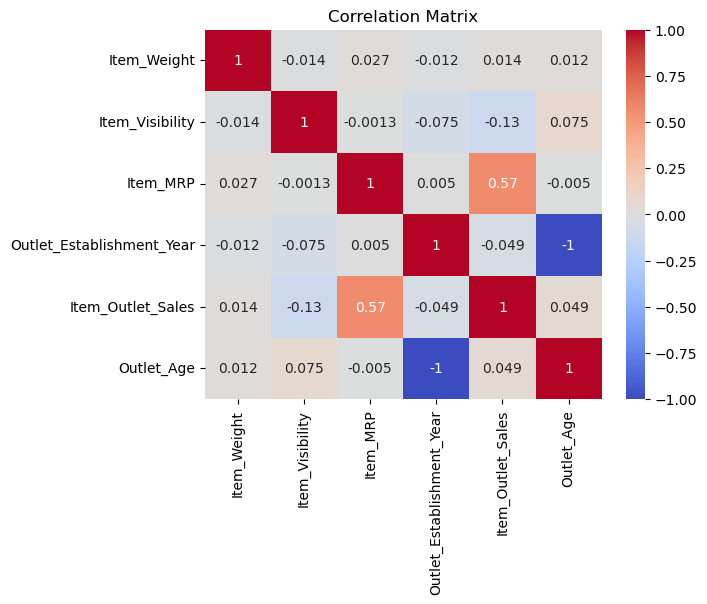

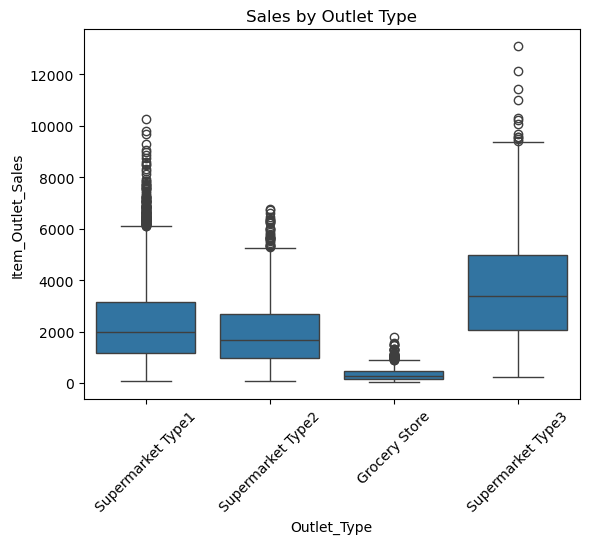

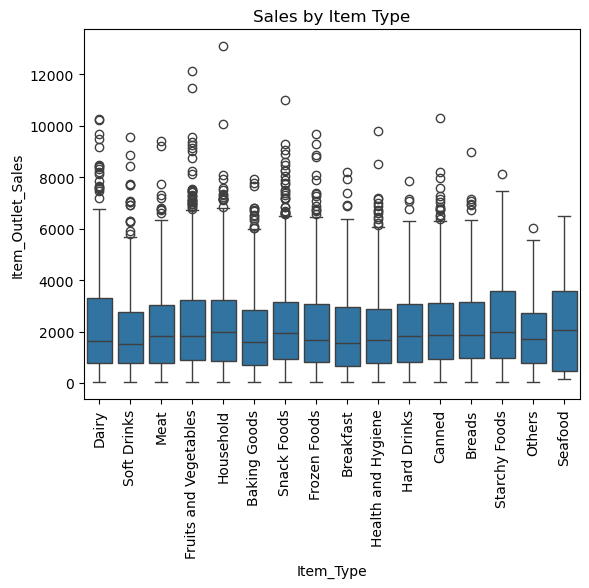

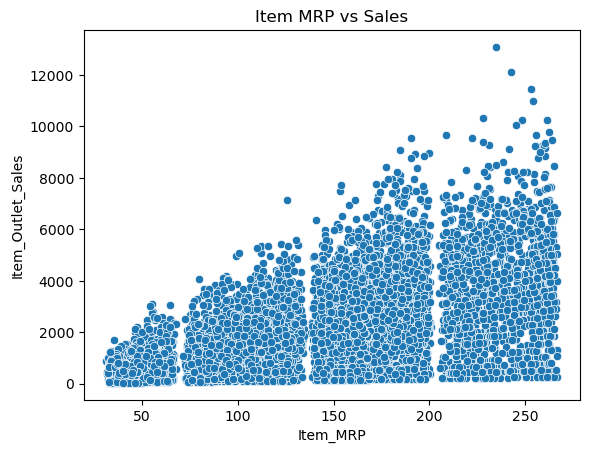

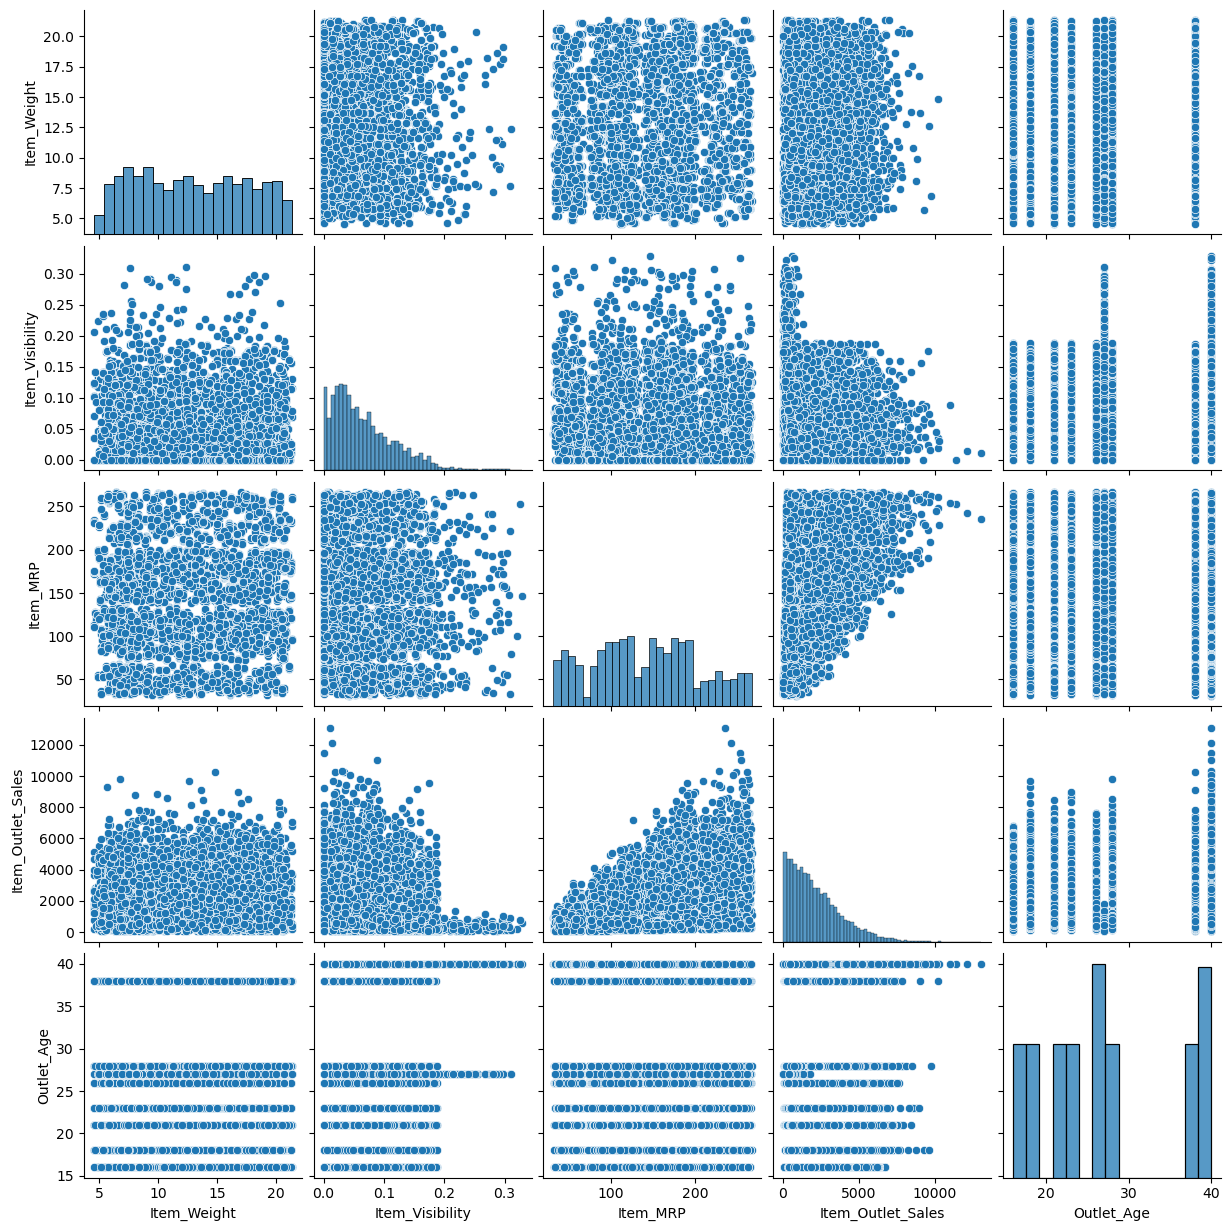

In [17]:
# Correlation matrix 
numerical_cols = train_df.select_dtypes(include=[np.number]).columns
corr = train_df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Sales by Outlet Type
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=train_df)
plt.xticks(rotation=45)
plt.title('Sales by Outlet Type')
plt.show()

# Sales by Item Type
sns.boxplot(x='Item_Type', y='Item_Outlet_Sales', data=train_df)
plt.xticks(rotation=90)
plt.title('Sales by Item Type')
plt.show()

# Scatterplot for MRP vs Sales
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=train_df)
plt.title('Item MRP vs Sales')
plt.show()


sns.pairplot(train_df[['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales', 'Outlet_Age']])
plt.show()

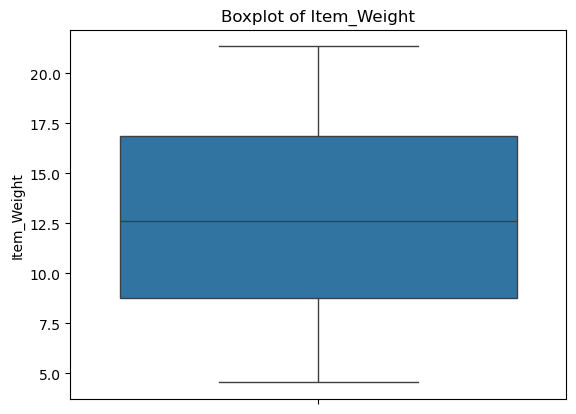

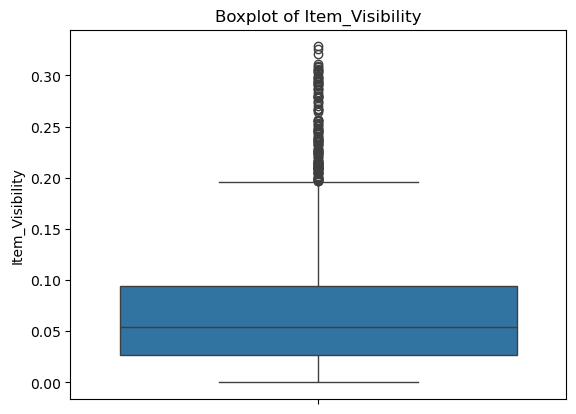

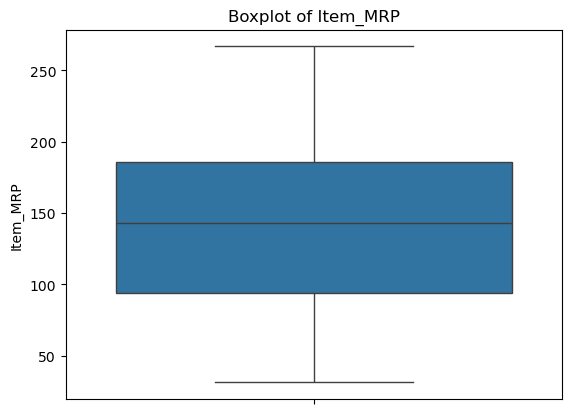

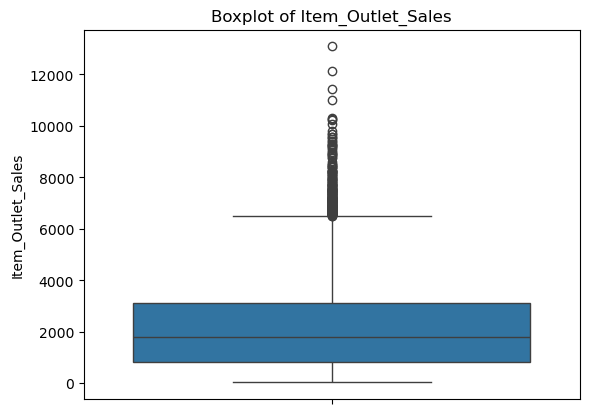

In [18]:
# Boxplot for outliers in numerical columns
for col in ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']:
    sns.boxplot(y=train_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Remove outliers in Item_Outlet_Sales using IQR
Q1 = train_df['Item_Outlet_Sales'].quantile(0.25)
Q3 = train_df['Item_Outlet_Sales'].quantile(0.75)
IQR = Q3 - Q1
train_df = train_df[(train_df['Item_Outlet_Sales'] >= Q1 - 1.5 * IQR) & (train_df['Item_Outlet_Sales'] <= Q3 + 1.5 * IQR)]

In [19]:
# Impute Item_Weight by using mean
train_df['Item_Weight'] = train_df.groupby('Item_Type')['Item_Weight'].transform(lambda x: x.fillna(x.mean()))
test_df['Item_Weight'] = test_df.groupby('Item_Type')['Item_Weight'].transform(lambda x: x.fillna(x.mean()))

# Impute Outlet_Size by using mode
def impute_outlet_size(df):
    mode_by_type = df.groupby('Outlet_Type')['Outlet_Size'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    df['Outlet_Size'] = df.apply(lambda row: mode_by_type[row['Outlet_Type']] if pd.isnull(row['Outlet_Size']) else row['Outlet_Size'], axis=1)
    return df

train_df = impute_outlet_size(train_df)
test_df = impute_outlet_size(test_df)


print(train_df.isnull().sum())
print(test_df.isnull().sum())

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Outlet_Age                   0
dtype: int64
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Outlet_Age                   0
dtype: int64


In [23]:
# Drop unnecessary columns
train_df.drop(['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year'], axis=1, inplace=True)
test_df.drop(['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year'], axis=1, inplace=True)


le = LabelEncoder()
for col in ['Item_Fat_Content']:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

categorical_cols = ['Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

test_df = test_df.reindex(columns=train_df.columns.drop('Item_Outlet_Sales'), fill_value=0)

KeyError: "['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year'] not found in axis"

In [24]:
X = train_df.drop('Item_Outlet_Sales', axis=1)
y = train_df['Item_Outlet_Sales']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print('RMSE:', np.sqrt(mean_squared_error(y_val, y_pred)))
print('R2 Score:', r2_score(y_val, y_pred))

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print('Cross-Validation R2 Scores:', cv_scores)
print('Mean CV R2:', cv_scores.mean())

RMSE: 1034.909768400176
R2 Score: 0.5240742925627457
Cross-Validation R2 Scores: [0.53925662 0.51636572 0.50984451 0.53802532 0.55100912]
Mean CV R2: 0.5309002581133656


In [25]:
# Train on full train data
model.fit(X, y)

# Predict on test
test_predictions = model.predict(test_df)

# Save predictions
submission = pd.DataFrame({'Predicted_Sales': test_predictions})
submission.to_csv('predictions.csv', index=False)
print('Predictions saved to predictions.csv')

Predictions saved to predictions.csv


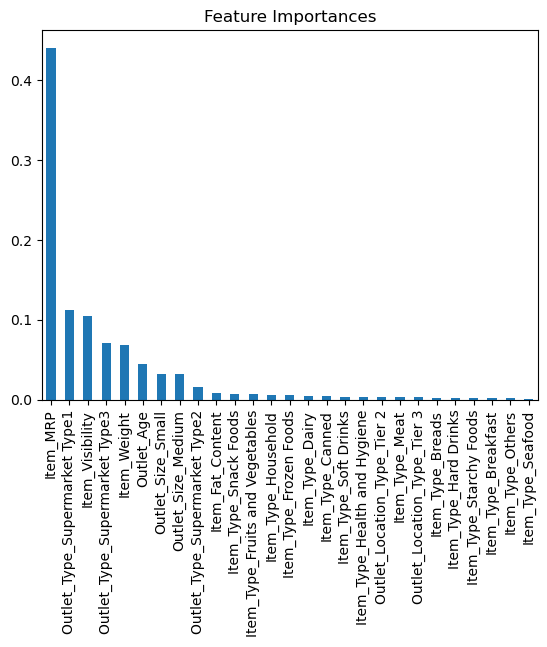

In [26]:
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feat_importances.plot(kind='bar')
plt.title('Feature Importances')
plt.show()